In [9]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import warnings
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
df_results = pd.read_csv('../metrics/model_comparison_ranking.csv')
df_sorted = df_results.sort_values('MAE')
df_sorted

,Model,MAE,RMSE,R2,MAPE,Time_sec
0,SVR,1.398633,1.860205,0.282401,0.017177,0.054560
1,CatBoost,1.427401,1.861015,0.281777,0.017457,0.443871
2,LinearRegression,1.434195,1.877129,0.269285,0.017559,0.014107
3,Voting_Ensemble,1.455152,1.923687,0.232588,0.017798,0.961518
4,XGBoost,1.469741,1.955781,0.206768,0.017994,0.121067
5,GradientBoosting,1.471141,1.928155,0.229019,0.017986,0.320952
6,RandomForest,1.490916,1.955638,0.206884,0.018223,0.521349


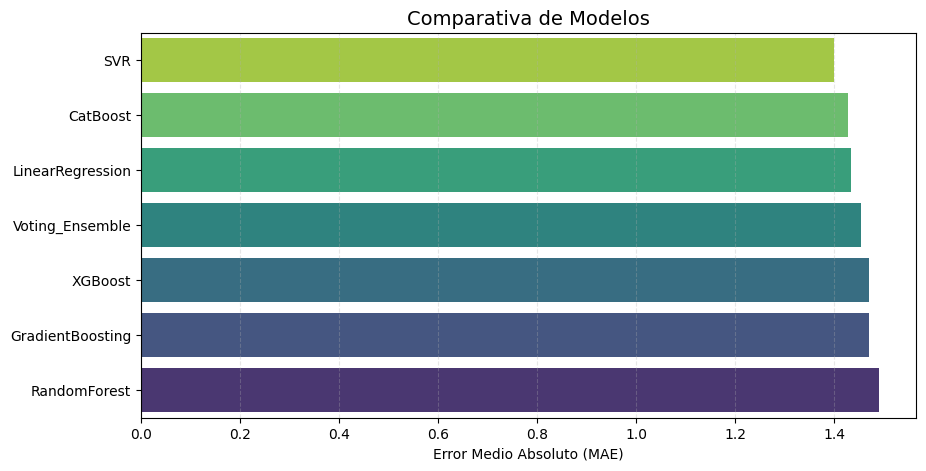

In [3]:
warnings.filterwarnings('ignore')
plt.figure(figsize=(10, 5))
df_for_plot = df_sorted.iloc[::-1] 
sns.barplot(x='MAE', y='Model', data=df_for_plot, palette='viridis', hue='Model', legend=False)
plt.gca().invert_yaxis() 
plt.title('Comparativa de Modelos', fontsize=14)
plt.xlabel('Error Medio Absoluto (MAE)')
plt.ylabel('') 
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

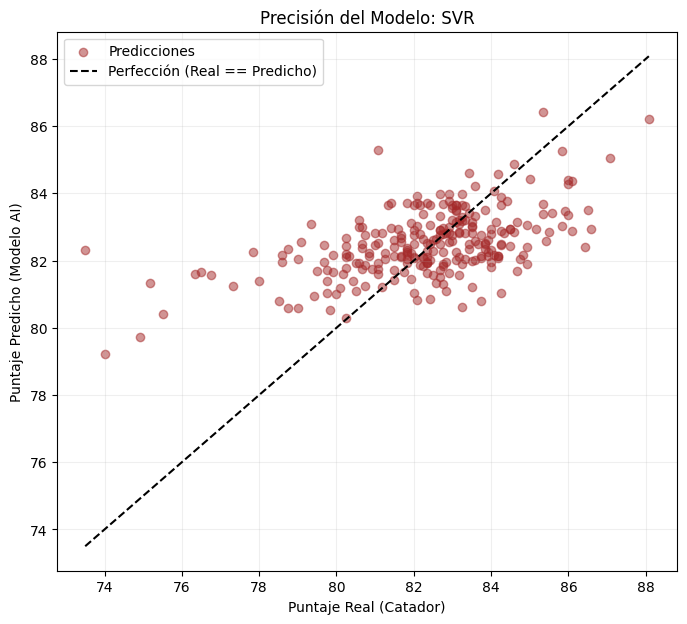

✅ Análisis finalizado para SVR. MAE: 1.3986


In [4]:
# 1. Configuración de Rutas
base_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
path_data = os.path.join(base_path, "data", "processed", "coffee_data_for_training.csv")
path_metrics = os.path.join(base_path, "metrics", "model_comparison_ranking.csv")
path_models = os.path.join(base_path, "models", "prediction")

# 2. Carga de datos y Split (idéntico al entrenamiento)
df = pd.read_csv(path_data)
target = 'Total.Cup.Points'
features_cat = ['Country.of.Origin', 'Region', 'Variety', 'Processing.Method', 'Color', 'categoria_altitud']
features_num = ['Moisture', 'Category.One.Defects', 'Category.Two.Defects', 'altitude_mean_meters']

X = df[features_cat + features_num]
y = df[target]

# Usamos random_state=42 para evaluar con los mismos datos que el script original descartó para train
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Carga del mejor modelo y Gráfico
if os.path.exists(path_metrics):
    df_results = pd.read_csv(path_metrics)
    best_model_name = df_results.iloc[0]['Model']
    model_file = os.path.join(path_models, f"coffee_model_{best_model_name}.pkl")
    
    # Cargar y predecir
    best_model = joblib.load(model_file)
    y_pred = best_model.predict(X_test)

    # Visualización minimalista
    plt.figure(figsize=(8, 7))
    plt.scatter(y_test, y_pred, alpha=0.5, color='brown', label='Predicciones')
    
    # Línea de 45 grados (Identidad)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    plt.plot(lims, lims, 'k--', lw=1.5, label='Perfección (Real == Predicho)') 
    
    plt.xlabel('Puntaje Real (Catador)')
    plt.ylabel('Puntaje Predicho (Modelo AI)')
    plt.title(f'Precisión del Modelo: {best_model_name}')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

    print(f"✅ Análisis finalizado para {best_model_name}. MAE: {mean_absolute_error(y_test, y_pred):.4f}")
else:
    print("❌ Error: No se encontró el ranking en /metrics. Ejecutá el entrenamiento primero.")

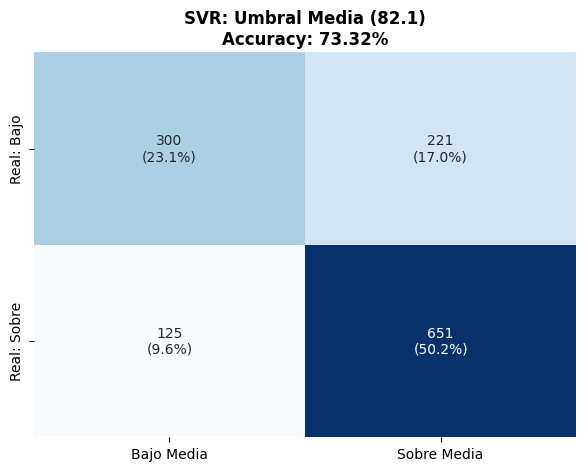

In [10]:
# 0. Aseguramos que el modelo esté cargado (Ajustá la ruta si es necesario)
model_svr = joblib.load('../models/prediction/coffee_model_SVR.pkl')

# 1. Preparación de datos (Media)
umbral_media = 82.1
y_real_media = (df['Total.Cup.Points'] >= umbral_media).astype(int)
y_pred_media = (model_svr.predict(X) >= umbral_media).astype(int)

# 2. Cálculo de matriz y porcentajes
cm_media = confusion_matrix(y_real_media, y_pred_media)
pct_media = cm_media.astype('float') / cm_media.sum()

# 3. Etiquetas combinadas (Número + %)
labels_media = [f"{v}\n({p:.1%})" for v, p in zip(cm_media.flatten(), pct_media.flatten())]
labels_media = np.asarray(labels_media).reshape(2,2)

# 4. Gráfico
plt.figure(figsize=(7, 5))
sns.heatmap(cm_media, annot=labels_media, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Bajo Media', 'Sobre Media'],
            yticklabels=['Real: Bajo', 'Real: Sobre'])

plt.title(f'SVR: Umbral Media ({umbral_media})\nAccuracy: {accuracy_score(y_real_media, y_pred_media):.2%}', fontweight='bold')
plt.show()

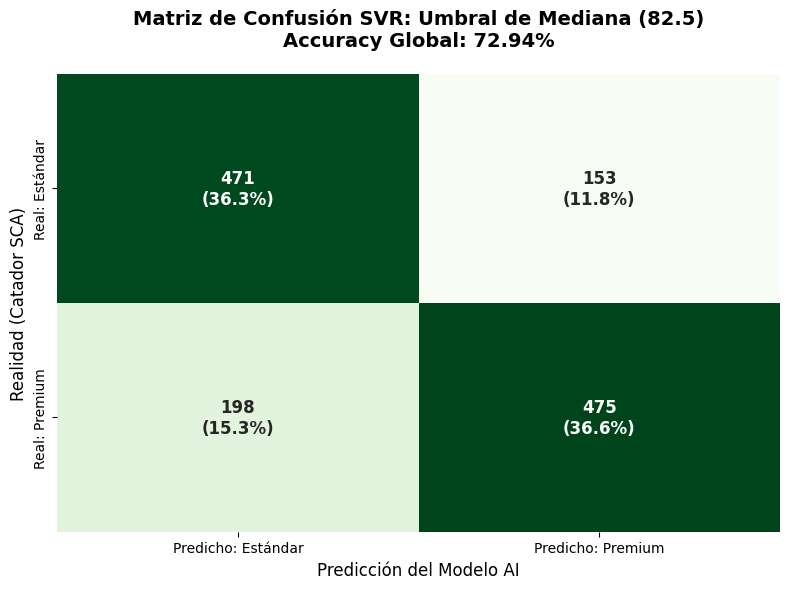

In [12]:
# 1. Preparación de datos (Mediana - El umbral elegido por balanceo)
umbral_mediana = 82.5
y_real_mediana = (df['Total.Cup.Points'] >= umbral_mediana).astype(int)
y_pred_mediana = (model_svr.predict(X) >= umbral_mediana).astype(int)

# 2. Cálculo de matriz y porcentajes
cm_mediana = confusion_matrix(y_real_mediana, y_pred_mediana)
pct_mediana = cm_mediana.astype('float') / cm_mediana.sum()

# 3. Etiquetas combinadas (Número absoluto + % del total)
# Usamos np.array para evitar conflictos de alias con pandas
labels_mediana = [f"{int(v)}\n({p:.1%})" for v, p in zip(cm_mediana.flatten(), pct_mediana.flatten())]
labels_finales = np.array(labels_mediana).reshape(2,2)

# 4. Visualización Estética
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mediana, annot=labels_finales, fmt='', cmap='Greens', cbar=False,
            xticklabels=['Predicho: Estándar', 'Predicho: Premium'],
            yticklabels=['Real: Estándar', 'Real: Premium'],
            annot_kws={"size": 12, "weight": "bold"})

plt.xlabel('Predicción del Modelo AI', fontsize=12)
plt.ylabel('Realidad (Catador SCA)', fontsize=12)
plt.title(f'Matriz de Confusión SVR: Umbral de Mediana ({umbral_mediana})\n'
          f'Accuracy Global: {accuracy_score(y_real_mediana, y_pred_mediana):.2%}', 
          fontsize=14, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()

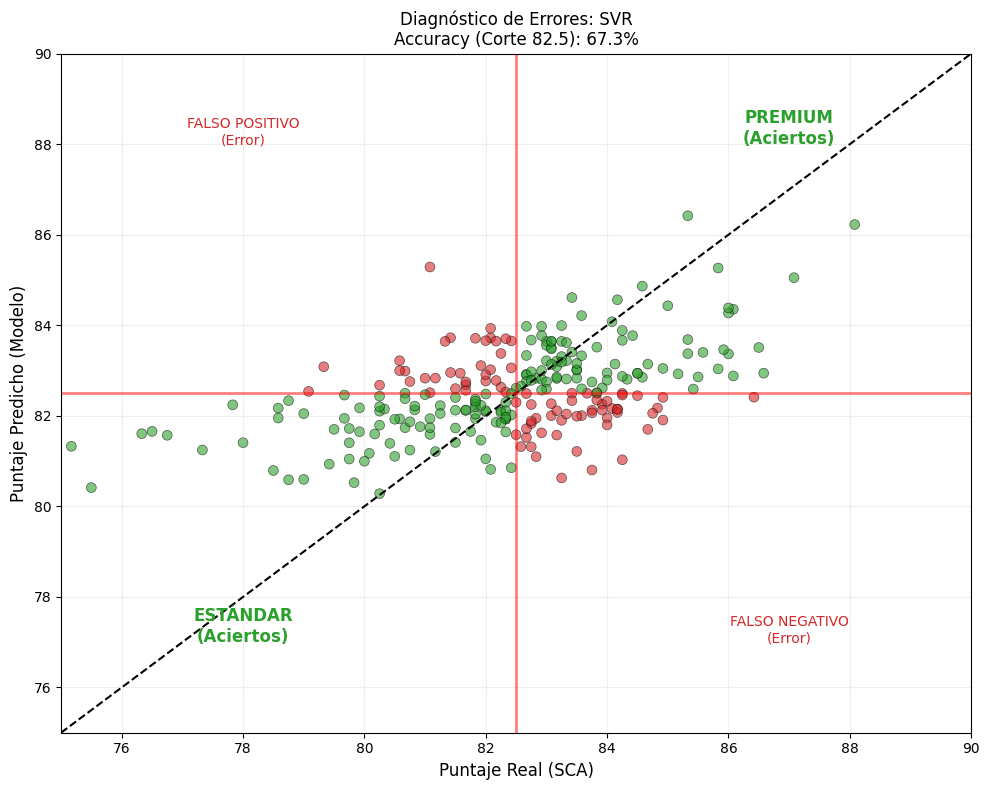

In [13]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Rutas
base_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
path_data = os.path.join(base_path, "data", "processed", "coffee_data_for_training.csv")
path_metrics = os.path.join(base_path, "metrics", "model_comparison_ranking.csv")
path_models = os.path.join(base_path, "models", "prediction")

# 2. Carga y Prep
df = pd.read_csv(path_data)
df = df[(df['Total.Cup.Points'] > 70) & (df['Total.Cup.Points'] < 92)]

target = 'Total.Cup.Points'
features_cat = ['Country.of.Origin', 'Region', 'Variety', 'Processing.Method', 'Color', 'categoria_altitud']
features_num = ['Moisture', 'Category.One.Defects', 'Category.Two.Defects', 'altitude_mean_meters']

X = df[features_cat + features_num]
y = df[target]
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Predicción con el mejor modelo
df_results = pd.read_csv(path_metrics)
best_model_name = df_results.iloc[0]['Model']
model_file = os.path.join(path_models, f"coffee_model_{best_model_name}.pkl")
best_model = joblib.load(model_file)
y_pred = best_model.predict(X_test)

# 4. Lógica de Colores (Acierto vs Error en Mediana 82.5)
umbral = 82.5
y_test_bin = (y_test >= umbral).astype(int)
y_pred_bin = (y_pred >= umbral).astype(int)
colores = np.where(y_test_bin == y_pred_bin, '#2ca02c', '#d62728') # Verde si acertó, Rojo si erró

# 5. Gráfico de Diagnóstico Final
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, c=colores, s=50, edgecolors='k', linewidths=0.5)

# Línea de Identidad y Cruz de Mediana
lims = [75, 90]
plt.plot(lims, lims, 'k--', lw=1.5, label='Perfección (Real == Predicho)')
plt.axhline(umbral, color='red', linestyle='-', alpha=0.5, lw=2)
plt.axvline(umbral, color='red', linestyle='-', alpha=0.5, lw=2)

# Textos de Cuadrantes
plt.text(87, 88, 'PREMIUM\n(Aciertos)', color='#2ca02c', fontsize=12, fontweight='bold', ha='center')
plt.text(78, 77, 'ESTÁNDAR\n(Aciertos)', color='#2ca02c', fontsize=12, fontweight='bold', ha='center')
plt.text(87, 77, 'FALSO NEGATIVO\n(Error)', color='#d62728', fontsize=10, ha='center')
plt.text(78, 88, 'FALSO POSITIVO\n(Error)', color='#d62728', fontsize=10, ha='center')

plt.xlabel('Puntaje Real (SCA)', fontsize=12)
plt.ylabel('Puntaje Predicho (Modelo)', fontsize=12)
plt.title(f'Diagnóstico de Errores: {best_model_name}\nAccuracy (Corte 82.5): {accuracy_score(y_test_bin, y_pred_bin):.1%}')
plt.xlim(lims); plt.ylim(lims)
plt.grid(True, alpha=0.2)
plt.tight_layout()

# Guardar para la presentación
# plt.savefig(os.path.join(base_path, "metrics", "diagnostico_errores.png"), dpi=300)
plt.show()

In [14]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

# 1. Configuración de entorno y carga de datos
MODELS_DIR = '../models/prediction'
df = pd.read_csv('../data/processed/coffee_data_for_training.csv')
df = df[(df['Total.Cup.Points'] > 70) & (df['Total.Cup.Points'] < 92)]

# 2. Re-crear el set de TEST (vital usar el mismo random_state=42)
target = 'Total.Cup.Points'
X = df.drop(columns=[target]) # O las columnas que usaste específicamente
y = df[target]
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Definir Umbral y función de métricas
umbral = 82.5
y_test_bin = (y_test >= umbral).astype(int)

def obtener_metricas_binarias(nombre, y_cont):
    y_pred_bin = (y_cont >= umbral).astype(int)
    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test_bin, y_pred_bin),
        'Precision': precision_score(y_test_bin, y_pred_bin),
        'Recall': recall_score(y_test_bin, y_pred_bin),
        'F1-Score': f1_score(y_test_bin, y_pred_bin),
        'AUC': roc_auc_score(y_test_bin, y_cont)
    }

# 4. Cargar y Evaluar TODOS los modelos guardados
resultados_finales = []
modelos_a_evaluar = ['SVR', 'CatBoost', 'LinearRegression', 'Voting_Ensemble', 'XGBoost', 'GradientBoosting', 'RandomForest']

for m_name in modelos_a_evaluar:
    path_model = os.path.join(MODELS_DIR, f'coffee_model_{m_name}.pkl')
    
    if os.path.exists(path_model):
        model = joblib.load(path_model)
        y_pred_cont = model.predict(X_test)
        
        res = obtener_metricas_binarias(m_name, y_pred_cont)
        resultados_finales.append(res)

# 5. Mostrar Tabla Comparativa Final
df_res = pd.DataFrame(resultados_finales).sort_values(by='F1-Score', ascending=False)
print(df_res.to_string(index=False))

          Modelo  Accuracy  Precision   Recall  F1-Score      AUC
             SVR  0.673077   0.710744 0.632353  0.669261 0.724472
         XGBoost  0.661538   0.706897 0.602941  0.650794 0.689338
 Voting_Ensemble  0.661538   0.718182 0.580882  0.642276 0.696306
LinearRegression  0.650000   0.702703 0.573529  0.631579 0.703125
GradientBoosting  0.642308   0.697248 0.558824  0.620408 0.690376
        CatBoost  0.642308   0.700935 0.551471  0.617284 0.704459
    RandomForest  0.630769   0.688679 0.536765  0.603306 0.689664


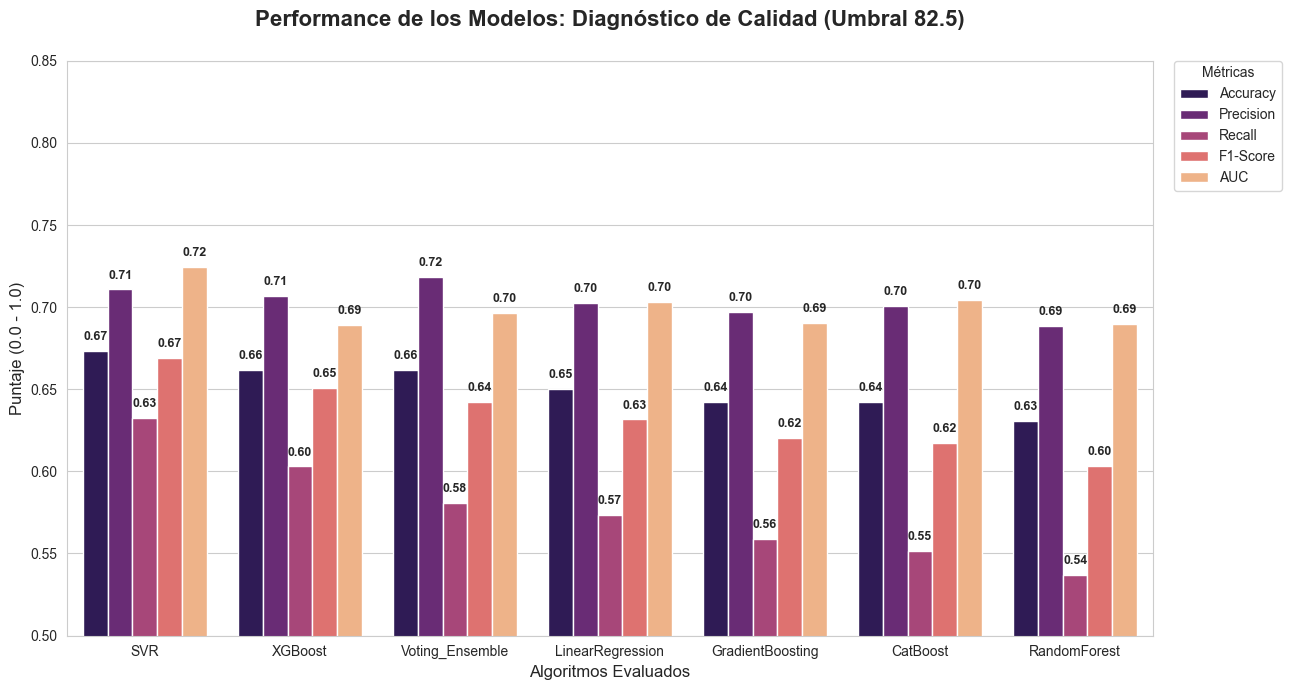

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Reestructurar datos para Seaborn (Formato 'Long' o 'Melt')
# Esto permite que Seaborn agrupe las barras por 'Métrica' automáticamente
df_melt = df_res.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

# 2. Configuración estética
plt.figure(figsize=(13, 7))
sns.set_style("whitegrid") # Fondo limpio para presentaciones

# 3. Crear el gráfico de barras agrupadas
ax = sns.barplot(
    data=df_melt, 
    x='Modelo', 
    y='Valor', 
    hue='Métrica', 
    palette='magma' # Una paleta profesional y con buen contraste
)

# 4. Personalización de ejes y títulos
plt.title('Performance de los Modelos: Diagnóstico de Calidad (Umbral 82.5)', 
          fontsize=16, fontweight='bold', pad=25)
plt.ylim(0.5, 0.85) # Ajustamos el foco a la zona donde hay variabilidad
plt.ylabel('Puntaje (0.0 - 1.0)', fontsize=12)
plt.xlabel('Algoritmos Evaluados', fontsize=12)

# 5. Añadir etiquetas de valor sobre cada barra (Data Labels)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=9,
                fontweight='bold')

# 6. Mover la leyenda afuera para que no tape los datos
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., title='Métricas')

plt.tight_layout()

# Opcional: Guardar para tu informe de Henry
# plt.savefig('../metrics/comparativa_modelos_clasificacion.png', dpi=300, bbox_inches='tight')

plt.show()

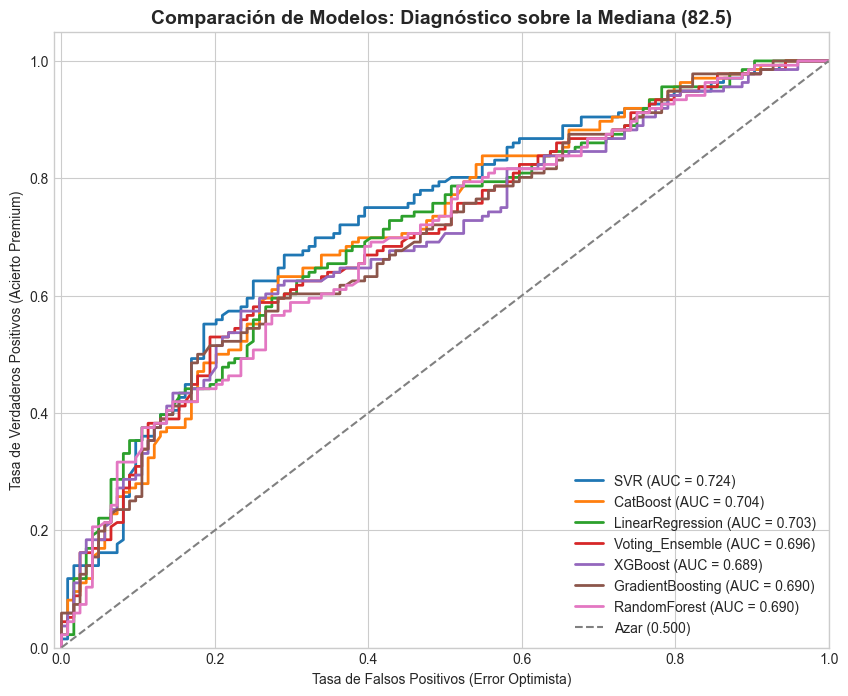


--- RANKING FINAL DE CLASIFICACIÓN ---
          Modelo  Accuracy  Precision   Recall  F1-Score      AUC
             SVR  0.673077   0.710744 0.632353  0.669261 0.724472
        CatBoost  0.642308   0.700935 0.551471  0.617284 0.704459
LinearRegression  0.650000   0.702703 0.573529  0.631579 0.703125
 Voting_Ensemble  0.661538   0.718182 0.580882  0.642276 0.696306
GradientBoosting  0.642308   0.697248 0.558824  0.620408 0.690376
    RandomForest  0.630769   0.688679 0.536765  0.603306 0.689664
         XGBoost  0.661538   0.706897 0.602941  0.650794 0.689338


In [15]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score, accuracy_score, precision_score, recall_score

# 1. Configuración de parámetros
umbral = 82.5
MODELS_DIR = '../models/prediction'
# Lista completa de todos los modelos que entrenaste
modelos_a_evaluar = ['SVR', 'CatBoost', 'LinearRegression', 'Voting_Ensemble', 'XGBoost', 'GradientBoosting', 'RandomForest']

# 2. Preparación de datos reales (Binarizados)
y_test_bin = (y_test >= umbral).astype(int)
resultados_lista = []

# 3. Creación del Gráfico ROC
plt.figure(figsize=(10, 8))
plt.style.use('seaborn-v0_8-whitegrid')

for name in modelos_a_evaluar:
    path = os.path.join(MODELS_DIR, f'coffee_model_{name}.pkl')
    
    if os.path.exists(path):
        model = joblib.load(path)
        y_score = model.predict(X_test) # Predicción continua para ROC
        y_pred_bin = (y_score >= umbral).astype(int) # Predicción binaria para métricas
        
        # Cálculo de métricas para la tabla
        fpr, tpr, _ = roc_curve(y_test_bin, y_score)
        roc_auc = auc(fpr, tpr)
        
        resultados_lista.append({
            'Modelo': name,
            'Accuracy': accuracy_score(y_test_bin, y_pred_bin),
            'Precision': precision_score(y_test_bin, y_pred_bin),
            'Recall': recall_score(y_test_bin, y_pred_bin),
            'F1-Score': f1_score(y_test_bin, y_pred_bin),
            'AUC': roc_auc
        })
        
        # Añadir línea al gráfico
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# 4. Estética del gráfico
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Azar (0.500)')
plt.xlim([-0.01, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Error Optimista)')
plt.ylabel('Tasa de Verdaderos Positivos (Acierto Premium)')
plt.title(f'Comparación de Modelos: Diagnóstico sobre la Mediana ({umbral})', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.show()

# 5. Tabla de resultados final
df_res = pd.DataFrame(resultados_lista).sort_values(by='AUC', ascending=False)
print("\n--- RANKING FINAL DE CLASIFICACIÓN ---")
print(df_res.to_string(index=False))